In [143]:
import torch
import MDAnalysis as mda
from torch_geometric.data import Data, InMemoryDataset
import numpy as np
import os
import os.path as osp
import warnings
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting

#from full_VGAE_egnn_clean import *

from torch.utils.data import random_split
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch
import pandas as pd
import torch_geometric.transforms as T
from torch_geometric.nn.pool import global_mean_pool
import math

from torch.utils.tensorboard import SummaryWriter
import itertools
from sklearn.preprocessing import StandardScaler

from scipy.spatial.distance import cdist

from tqdm import tqdm


## Dataset generation and preprocessing

In [144]:
import sys
sys.path.append("LIBS")
from LIBS.utils import *
from LIBS.FGVAE import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Pretrained original model GVAE

In [145]:
#path = '../JIMI_RUNS/hybrid_displacement/force_field/no_field_good_sim/'

#path = '../RUNS/hybrid_displacement/test_positions/test_tanh_norm_no_ff_1/'

# path = '../JIMI_RUNS/hybrid_displacement/random_pos_ref_batch/bonds_angle_lj_1/'
# parameters = parse_config(path + 'full_ff_long.in')



#path = '../RUNS/hybrid_displacement/random_pos_ref_batch/pre-train/' #bonds_angle_lj_210/'

path = '../RUNS/hybrid_displacement/aligned_mean_ref_bigger/train_bonds_angles_low_kl_90/'

parameters = parse_config(path + 'config.template.in')

LOAD_MODEL_FROM_EPOCH = 100

In [146]:
#parameters = parse_config('config.template.in')


MODEL_ARCHITECTURE = parameters['MODEL_ARCHITECTURE']  # 'EGNN'
ENCODER_POS_PROJECTION_DIM = parameters['ENCODER_POS_PROJECTION_DIM']  # 128

#encoder - Updated based on the saved model structure
HIDDEN_ENCODER_CHANNELS = parameters['HIDDEN_ENCODER_CHANNELS']  # 256
OUT_ENCODER_CHANNELS = parameters['OUT_ENCODER_CHANNELS']  # 128
NUM_ENC_LAYERS = parameters['NUM_ENC_LAYERS']  # 9
ATTENTION_ENCODER = parameters['ATTENTION_ENCODER']  # True
LATENT_DIM = parameters['LATENT_DIM']  # 128
TANH_ENCODER = parameters['TANH_ENCODER']  # False
NORMALIZE_ENCODER = parameters['NORMALIZE_ENCODER']  # False

#decoder
MLP_DECODER_POS_SIZE = parameters['MLP_DECODER_POS_SIZE']  # [256, 256, 128]
HIDDEN_DECODER_CHANNELS = parameters['HIDDEN_DECODER_CHANNELS']  # 256
NUM_DEC_LAYERS = parameters['NUM_DEC_LAYERS']  # 9  # Should match encoder layers
ATTENTION_DECODER = parameters['ATTENTION_DECODER']  # True
TANH_DECODER = parameters['TANH_DECODER']
NORMALIZE_DECODER = parameters['NORMALIZE_DECODER']  # False    

#### dataset parameters
INCLUDE_ATOM_TYPE = parameters['INCLUDE_ATOM_TYPE']  # True
SCALE_POSITIONS = parameters['SCALE_POSITIONS']  # False
SCALE_FEATURES = parameters['SCALE_FEATURES']  # True
INITIAL_ALIGNMENT = parameters['INITIAL_ALIGNMENT']  # False

#### training parameters
EPOCHS = parameters['EPOCHS']  # 1000
BATCHSIZE = parameters['BATCHSIZE']  # 128
LEARNING_RATE = parameters['LEARNING_RATE']  # 1E-5
WEIGHT_DECAY = parameters['WEIGHT_DECAY']  # 0
advanced_recon_loss = parameters['advanced_recon_loss']  # True

#### Scheduler parameters
USE_SCHEDULER =  parameters['USE_SCHEDULER']  # False
SCHEDULER_PATIENCE =  parameters['SCHEDULER_PATIENCE']  # 10
SCHEDULER_FACTOR = parameters['SCHEDULER_FACTOR']  # 0.5
SCHEDULER_TYPE = parameters['SCHEDULER_TYPE']  # ReduceLROnPlateau
SCHEDULER_THRESHOLD =  parameters['SCHEDULER_THRESHOLD']  # 0.0001

# Beta annealing parameters
BETA = parameters['BETA']  # None
wait_epochs = parameters['wait_epochs']  # 10
annealing_epochs = parameters['annealing_epochs']  # 100
beta_min = parameters['beta_min']  # 0.00001
beta_max = parameters['beta_max']  # 0.01

# force field parameters
USE_FORCE_FIELD = parameters['USE_FORCE_FIELD']  # True
PDB_FOR_ENERGY = parameters['PDB_FOR_ENERGY']  # ../DATA/raw/protein_only.pdb
LAMBDA_ENERGY = parameters['LAMBDA_ENERGY']  # None
wait_lambda_epochs = parameters['wait_lambda_epochs']  # 10
lambda_annealing_epochs = parameters['lambda_annealing_epochs']  # 500
lambda_min = parameters['lambda_min']  # 0
lambda_max = parameters['lambda_max']  # 0.0001

USE_LOG_FF = parameters['USE_LOG_FF']  # False
# if True, the force field loss is calculated using log scaling, otherwise it is calculated using the raw values
USE_BOND_FF = parameters['USE_BOND_FF']  # True
# if True, the bonded energy is included in the force field loss
USE_ANGLE_FF = parameters['USE_ANGLE_FF']  # False
# if True, the angle energy is included in the force field loss
USE_LJ_FF = parameters['USE_LJ_FF']  # False
# if True, the Lennard-Jones energy is included in the force field loss

# Other parameters
DISABLE_TQDM = parameters['DISABLE_TQDM']  # False
SEED = parameters['SEED']  # 42
NAME_SIMULATION = parameters['NAME_SIMULATION']  # pos_nm
NAME_FOLDER = parameters['NAME_FOLDER']  # new_diff_PINN

CONTINUE_FROM = parameters['CONTINUE_FROM']  # None
STARTING_EPOCH = parameters['STARTING_EPOCH']  # 0
ALIGN_RECONS_LOSS = parameters['ALIGN_RECONS_LOSS']  # Trye
TEST_MODEL = parameters['TEST_MODEL']  # True
MIN_KL = parameters['MIN_KL']  # 1.


In [147]:
dataset = get_dataset( include_atom_type=INCLUDE_ATOM_TYPE,
                       scale_features=SCALE_FEATURES,
                       scale_pos=SCALE_POSITIONS,
                       initial_alignment=INITIAL_ALIGNMENT,
                       return_pos_angstrom=False)

Loading dataset ...
Root directory: None
TPR file: MD.tpr
Trajectory file: MD_with_solvent_noPBC.xtc
Selection: protein
Include atom type: True
Scale features: True
Scale positions: False
Initial alignment: True
Return max position: False
Return position in Angstrom: False
No root directory provided, using default path ...
Successfully loaded processed data from /home/clod/Desktop/THESIS_2/FULL_ATOM/DATA/processed/data_MD_protein.pt
Converting positions to nm ...
Positions shape: torch.Size([20032, 52, 3])
Including atom features: performing one hot encoding ...
Scaling features ...
Aligning the first frame to the origin ...
Aligning all the other frame to the first frame ...
Dataset created with 20032 graphs.
Number of graphs in the dataset: 20032
Number of features in the dataset: 6
Number of edges in the dataset: 102
Number of nodes in the dataset: 52
Number of features in the dataset: torch.Size([52, 6])



In [148]:
print("example of positions")
print(dataset[0].pos[:10])  # Show first 10 positions

# get min and max of the dataset
pos_min = dataset[0].pos.min(dim=0).values
pos_max = dataset[0].pos.max(dim=0).values
print(f"Min position: {pos_min}")
print(f"Max position: {pos_max}")

example of positions
tensor([[-0.6320, -0.1757,  0.5983],
        [-0.7300, -0.1637,  0.5523],
        [-0.6460, -0.2397,  0.6853],
        [-0.5970, -0.0777,  0.6313],
        [-0.5240, -0.2277,  0.5043],
        [-0.4630, -0.3277,  0.5423],
        [-0.5190, -0.1777,  0.3803],
        [-0.5770, -0.0967,  0.3663],
        [-0.4110, -0.2057,  0.2883],
        [-0.3300, -0.2507,  0.3453]])
Min position: tensor([-0.7300, -0.4007, -0.6437])
Max position: tensor([0.7630, 0.3633, 0.6853])


In [149]:
# load the model 
model = FGVAE(
        encoder=EGNN_Encoder(
            in_channels=dataset[0].num_features,
            hidden_channels_egnn=HIDDEN_ENCODER_CHANNELS,
            out_channels_egnn=OUT_ENCODER_CHANNELS,
            num_egnn_layers=NUM_ENC_LAYERS,
            latent_dim=LATENT_DIM,
            attention=ATTENTION_ENCODER,
            architecture=MODEL_ARCHITECTURE,
            pos_projection_dim=ENCODER_POS_PROJECTION_DIM,
            tanh=TANH_ENCODER,
            normalize=NORMALIZE_ENCODER,
            verbose=True
        ),
        decoder=EGNN_Decoder(
            latent_dim=LATENT_DIM,
            node_feature_dim_initial=dataset[0].num_features,
            hidden_nf=HIDDEN_DECODER_CHANNELS,
            num_egnn_layers=NUM_DEC_LAYERS,
            attention=ATTENTION_DECODER,
            architecture=MODEL_ARCHITECTURE,
            pos_MLP_size=MLP_DECODER_POS_SIZE,
            tanh=TANH_DECODER,
            normalize=NORMALIZE_DECODER,

            verbose=True
        )
    ).to(device)

epochs = LOAD_MODEL_FROM_EPOCH

# Try loading with strict=False to see what parameters don't match
path_model = f'model_epoch_{epochs}.pth'
try:
    model.load_state_dict(torch.load(os.path.join(path, path_model)), strict=True)
    print("Model loaded successfully")
except Exception as e:
    print(f"Error loading model: {e}")

print_model_summary(model)



Encoder initialized with in_channels=6, hidden_channels_egnn=256, out_channels_egnn=64, num_egnn_layers=5, latent_dim=6
Architecture: hybrid_displacement
Position projection dimension: 6
Number of nodes: 52
Using attention mechanism in EGNN
Using tanh activation in EGNN
Decoder initialized with latent_dim=6, node_feature_dim_initial=6, hidden_nf=256, num_egnn_layers=6, out_coord_dim=3
Architecture: hybrid_displacement
Initial position MLP sizes: [128, 64, 128]
Using attention mechanism in EGNN
Using tanh activation in EGNN for coordinates MLP
Coordinates will be normalized in EGNN
Model loaded successfully
MODEL SUMMARY
encoder.project                                    | Linear(in_features=6, out_features=256, bias=True)           |      1,792 |      1,792
encoder.egnn.embedding_in                          | Linear(in_features=6, out_features=256, bias=True)           |      1,792 |      1,792
encoder.egnn.embedding_out                         | Linear(in_features=256, out_features=64

In [150]:
# Calculate the mean reference structure for hybrid displacement
print("Calculating mean reference structure for the hybrid model...")

Aligned_dataset = get_dataset(include_atom_type=INCLUDE_ATOM_TYPE,
                             scale_features=SCALE_FEATURES,
                             scale_pos=SCALE_POSITIONS,
                             initial_alignment=True,
                             return_pos_angstrom=False) 



all_pos = torch.stack([data.pos for data in Aligned_dataset], dim=0)  # Shape: (num_graphs, num_atoms, 3)
pos_ref_single = all_pos.mean(dim=0).to(device)  # Shape: (num_atoms, 3)

# pos_ref_single = dataset[0].pos  
# pos_ref_single = pos_ref_single.to(device)  # Move to device


dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
model.eval()

recon_positions = []
with torch.no_grad():
    for data in tqdm(dataloader, desc="Evaluating model"):
        data = data.to(device)
        pos_recon, _, _, _= model(data, pos_ref=pos_ref_single)
        recon_positions.append(pos_recon)


Calculating mean reference structure for the hybrid model...
Loading dataset ...
Root directory: None
TPR file: MD.tpr
Trajectory file: MD_with_solvent_noPBC.xtc
Selection: protein
Include atom type: True
Scale features: True
Scale positions: False
Initial alignment: True
Return max position: False
Return position in Angstrom: False
No root directory provided, using default path ...
Successfully loaded processed data from /home/clod/Desktop/THESIS_2/FULL_ATOM/DATA/processed/data_MD_protein.pt
Converting positions to nm ...
Positions shape: torch.Size([20032, 52, 3])
Including atom features: performing one hot encoding ...
Scaling features ...
Aligning the first frame to the origin ...
Aligning all the other frame to the first frame ...
Dataset created with 20032 graphs.
Number of graphs in the dataset: 20032
Number of features in the dataset: 6
Number of edges in the dataset: 102
Number of nodes in the dataset: 52
Number of features in the dataset: torch.Size([52, 6])



Evaluating model: 100%|██████████| 20032/20032 [01:51<00:00, 180.00it/s]


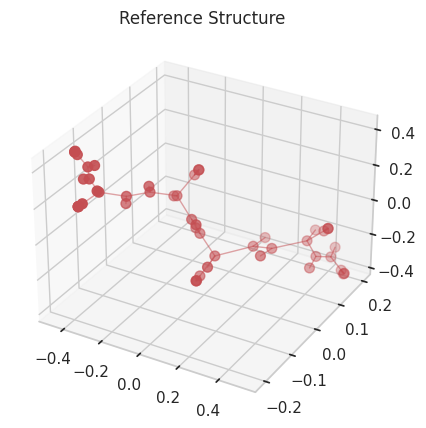

In [151]:
# plot the reference structure

def plot_single_graph(pos, edge_index, figsize=(5, 5), title='Reference Structure', color='r', save_path=None):
    G = to_networkx(Data(pos=pos, edge_index=edge_index), to_undirected=True)
    pos_3d = pos

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=50, c=color, label='Reference Structure')
    for edge in G.edges():
            x = [pos[edge[0], 0], pos[edge[1], 0]]
            y = [pos[edge[0], 1], pos[edge[1], 1]]
            z = [pos[edge[0], 2], pos[edge[1], 2]]
            ax.plot(x, y, z, alpha=0.5, color=color, linewidth=1)

    # nx.draw(G, pos=pos_3d, ax=ax, with_labels=True, node_size=50, font_size=8)
    ax.set_title(title)
    
    if save_path:
        plt.savefig(save_path)
    plt.show()

pos_ref_single = pos_ref_single.cpu().numpy()  # Convert to numpy for plotting
plot_single_graph(pos_ref_single, dataset[0].edge_index, title='Reference Structure', save_path=None)

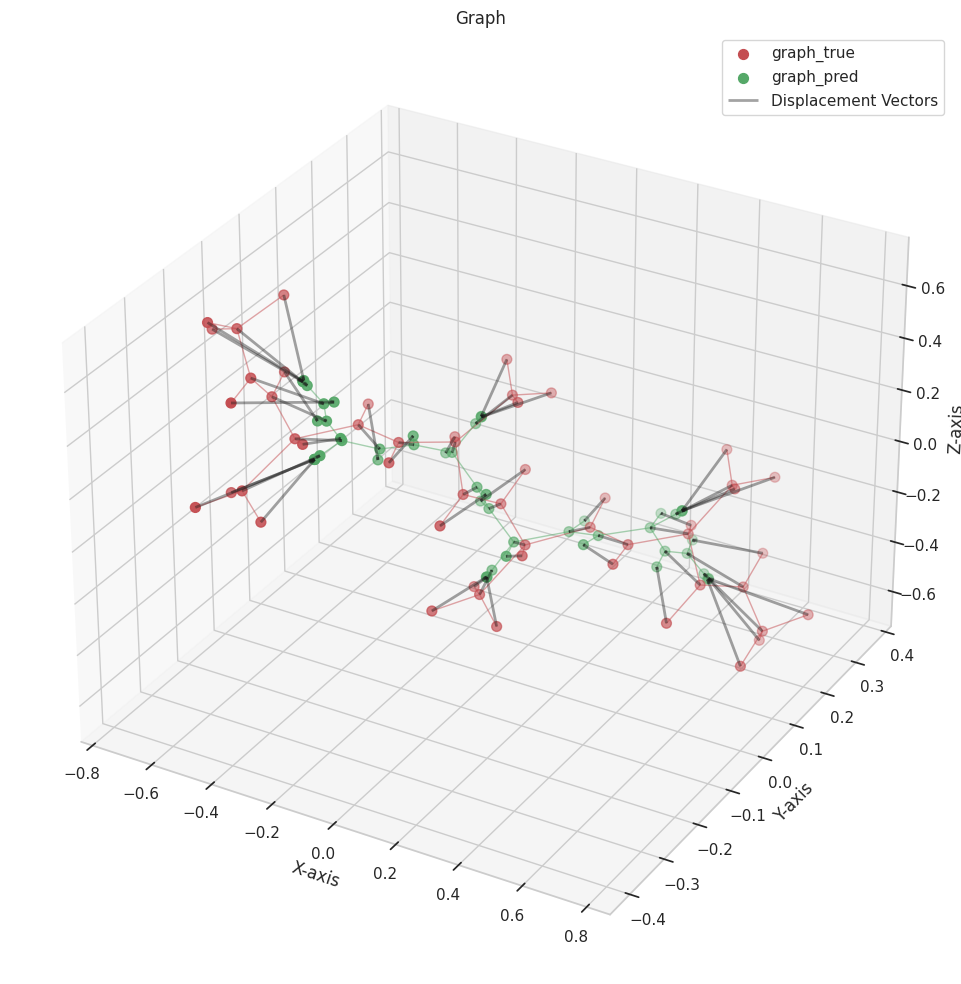

In [152]:
plot_graph_pred(torch.tensor(pos_ref_single, dtype=torch.float32), dataset[0])

In [153]:
sys.path.append("LIBS")
from LIBS.force_field import EnergyCalculator
from LIBS.utils import *
# compute energy for the reference structure
pdbfile = '../DATA/raw/protein_only.pdb'
physics_critic = EnergyCalculator(pdbfile)

energy = physics_critic.openMM_energy(torch.tensor(pos_ref_single, dtype=torch.float32))

print(f"Energy of the reference structure: {energy:.2e} kcal/mol")


Using OpenMM platform: CUDA
Energy of the reference structure: 3.46e+06 kcal/mol


In [154]:
from LIBS.utils import advanced_reconstruction_loss as arl

batch = torch.tensor([0] * len(dataset[0].pos), dtype=torch.long, device=device)  # Assuming all data belongs to batch 0
batch = batch.to(device)

losses = []
for i, data in enumerate(dataset):
    data = data.to(device)  # Ensure data is on the correct device
    pos = data.pos.to(device)
    pos_recon = recon_positions[i]
    
    # Calculate the loss
    loss = arl(pos_recon, data.pos, data.edge_index, batch)
    losses.append(loss)

Best reconstruction loss: 0.004836949519813061 for peptide index 9129


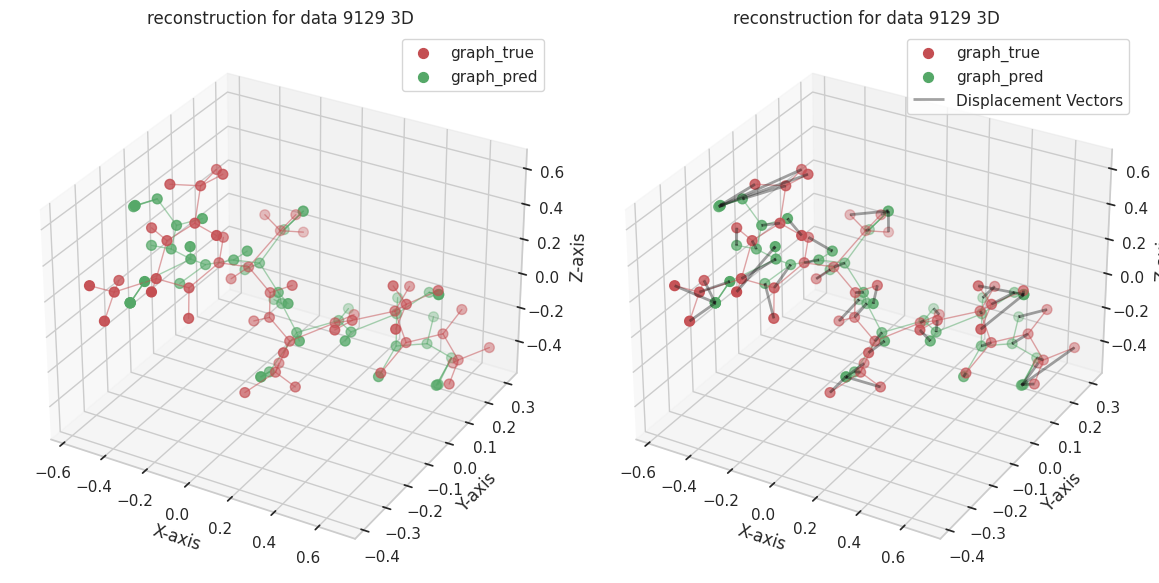

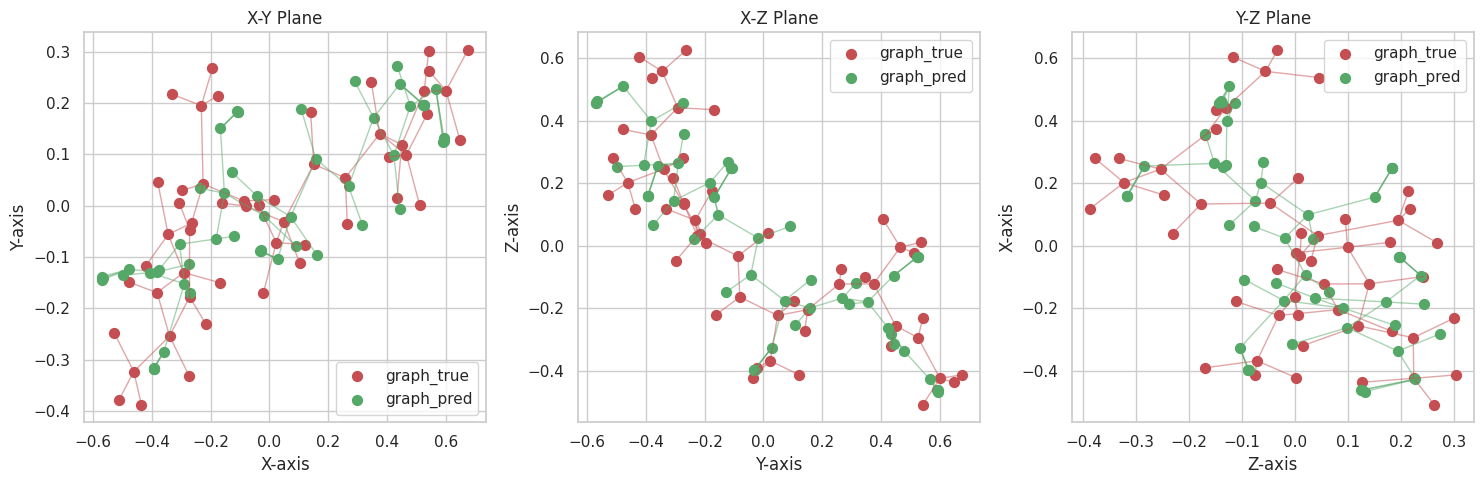

In [155]:
losses = torch.tensor(losses, dtype=torch.float32, device=device)
losses = losses.cpu().numpy()  # Convert to numpy for further processing

best_index = np.argmin(losses).item()
print(f"Best reconstruction loss: {losses[best_index]} for peptide index {best_index}")

pos_recon_best = recon_positions[best_index].cpu()
data_true_best = dataset[best_index]

fig, ax = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': '3d'})

R,t = find_rigid_alignment(pos_recon_best, data_true_best.pos)
aligned_pos_recon_best = pos_recon_best @ R.T + t

plot_graph_pred(aligned_pos_recon_best, data_true_best, ax=ax[0], title=f"reconstruction for data {best_index} 3D", planewise=False,quiver=False)
plot_graph_pred(aligned_pos_recon_best, data_true_best, ax=ax[1], title=f"reconstruction for data {best_index} 3D", planewise=False)
plot_graph_pred(aligned_pos_recon_best, data_true_best, title=f"reconstruction for data {best_index} 2D", planewise=True,quiver=False)



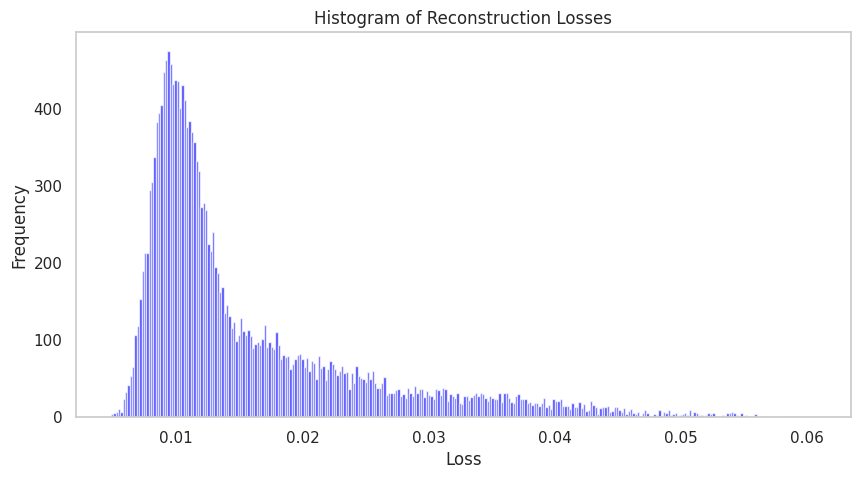

In [156]:
# Plot an histogram of the losses
plt.figure(figsize=(10, 5))
plt.hist(losses, bins=300, color='blue', alpha=0.7)
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of Reconstruction Losses')
plt.grid()
plt.show()

For now, the features for the nodes are:
- atom type (one hot encoded)
- charge
- mass

For the edges there are no attributes

# Analysis of the distances between bonded atoms ( bond distance)

### Histogram of the distances from the original dataset

Number of edges: 51
distances shape: torch.Size([51])
distances mean: 0.12310478836297989
distances std: 0.018703918904066086


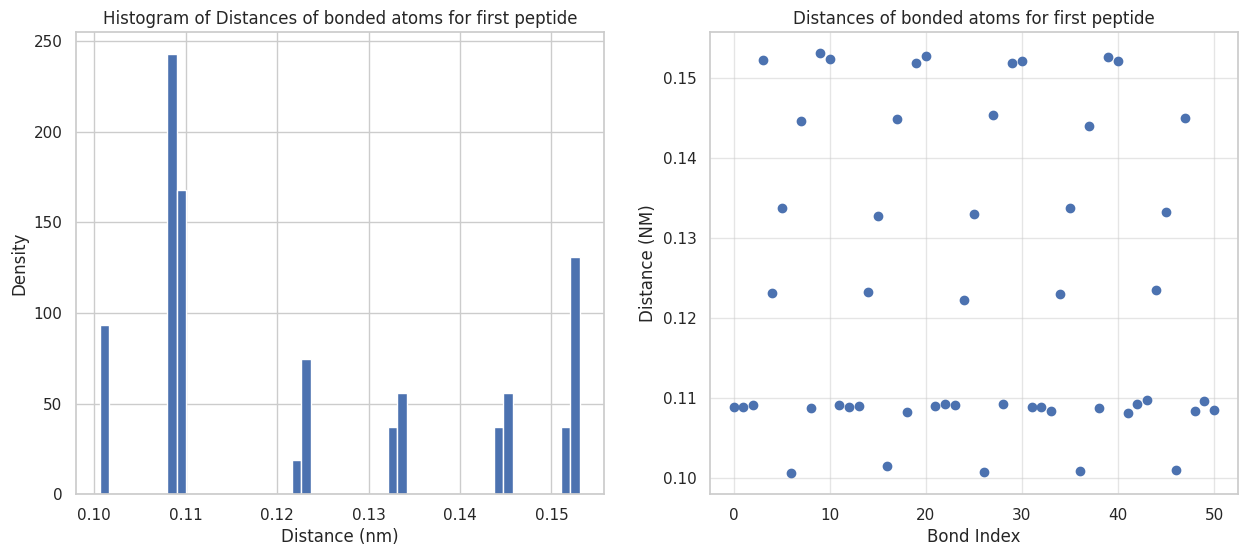

In [157]:
data = dataset[0]
pos = data.pos
edge_index = data.edge_index


fig, ax = plt.subplots(1,2, figsize=(15,6))
# plot an histogram of the distances between atoms

edge_index_single = edge_index[:, edge_index[0] < edge_index[1]]
distances = torch.norm(pos[edge_index_single[0]] - pos[edge_index_single[1]], dim=1)

print("Number of edges:", edge_index_single.shape[1])
print("distances shape:", distances.shape)
print("distances mean:", distances.mean().item())
print("distances std:", distances.std().item())

ax[0].hist(distances.numpy(), bins=50, density=True)
ax[0].set_xlabel(r'Distance (nm)')
ax[0].set_ylabel('Density')
ax[0].set_title('Histogram of Distances of bonded atoms for first peptide')


ax[1].plot(np.arange(len(distances)), distances.numpy(), 'o')
ax[1].set_xlabel('Bond Index')
ax[1].set_ylabel(r'Distance (NM)')
ax[1].set_title('Distances of bonded atoms for first peptide')
ax[1].grid(alpha=0.5)
plt.show()



Typical length of the bonds inside tetraalanine
| **Bond Type**      | **Distance (Å)** |
| ------------------ | ---------------- |
| N–H                | \~1.01 Å         |
| C–N (peptide bond) | \~1.33 Å         |
| C=O                | \~1.23 Å         |
| C–C                | \~1.52 – 1.54 Å  |
| C–H                | \~1.09 Å         |
| O–H                | \~0.96 Å         |



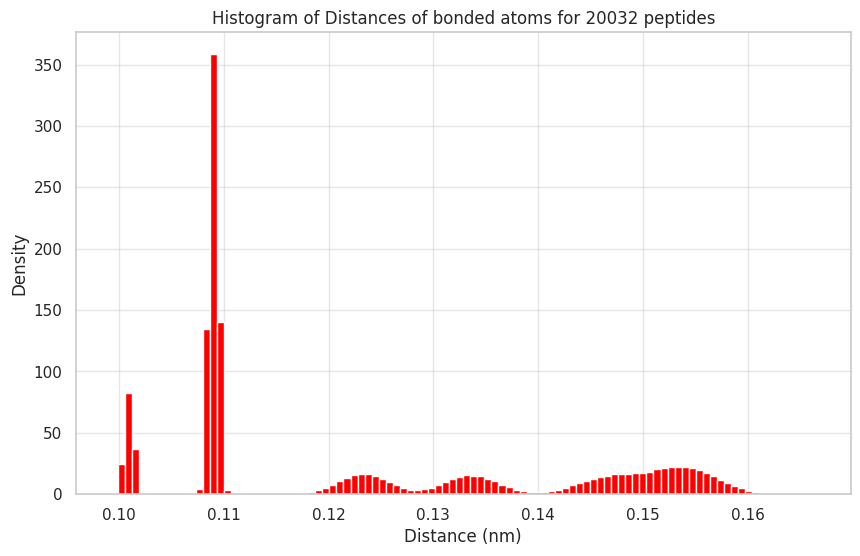

distances shape: torch.Size([1021632])
Distances mean: 0.12361741065979004
Distances std: 0.019184742122888565


In [158]:
# here I can use edge_index_single from before since it the same for all peptides
true_distances = []
n_peptides = len(dataset)
for data in dataset[:n_peptides]:
    pos = data.pos
    
    # plot an histogram of the distances between atoms
    true_distances.append(torch.norm(pos[edge_index_single[0]] - pos[edge_index_single[1]], dim=1))

true_distances = torch.cat(true_distances)
fig_original =plt.figure(figsize=(10, 6))
plt.hist(true_distances, bins=100, color='red', density=True)
plt.xlabel(r'Distance (nm)')
plt.ylabel('Density')
plt.title(f'Histogram of Distances of bonded atoms for {n_peptides} peptides')
plt.grid(alpha=0.5)
plt.show()

print ("distances shape:", true_distances.shape)
print("Distances mean:", true_distances.mean().item())
print("Distances std:", true_distances.std().item())

## Histogram of the reconstructed distances

Number of peptides: 20032


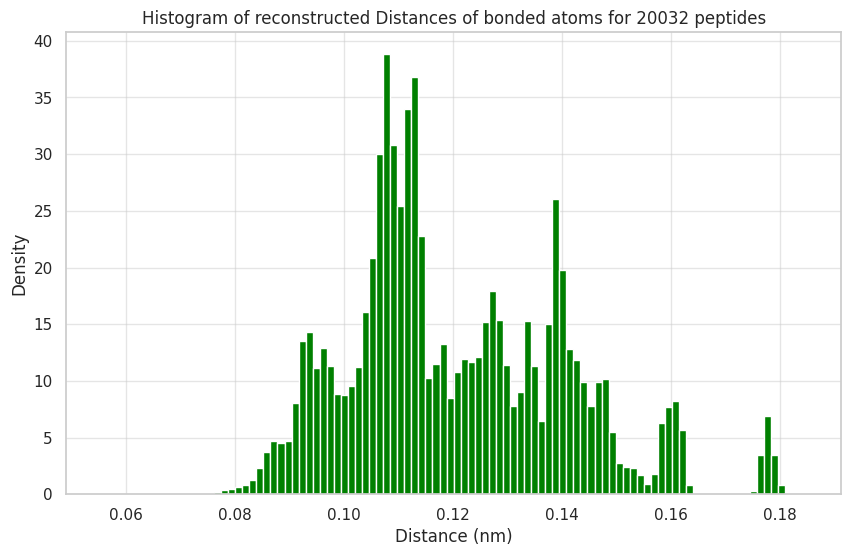

distances shape: torch.Size([1021632])
Distances mean: 0.12045940011739731
Distances std: 0.019949445500969887


In [159]:
# here I can use edge_index_single from before since it the same for all peptides
# rescale back to original scale
#max_pos = torch.tensor([28.9800, 29.0000, 29.0100])

pos_recon_rescaled_tensor = torch.stack(recon_positions, dim=0)#* max_pos.to(device)
# Move to CPU and convert to numpy
pos_recon_rescaled_tensor = pos_recon_rescaled_tensor.cpu()
pos_recon_rescaled = pos_recon_rescaled_tensor.cpu().numpy()

pos_true = torch.stack([data.pos for data in dataset], dim=0) 

distances = []
n_peptides = pos_recon_rescaled_tensor.shape[0]
print("Number of peptides:", n_peptides)

# plot an histogram of the distances between atoms
for pos in pos_recon_rescaled_tensor:

    # plot an histogram of the distances between atoms
    distances.append(torch.norm(pos[edge_index_single[0]] - pos[edge_index_single[1]], dim=1))

distances = torch.cat(distances)

fig_reconstructed = plt.figure(figsize=(10, 6))
plt.hist(distances, bins=100, color = 'green', density=True)
plt.xlabel(r'Distance (nm)')
plt.ylabel('Density')
plt.title(f'Histogram of reconstructed Distances of bonded atoms for {n_peptides} peptides')
plt.grid(alpha=0.5)
plt.show()

print ("distances shape:", distances.shape)
print("Distances mean:", distances.mean().item())
print("Distances std:", distances.std().item())

In [160]:
# save the trajectories
torch.save(pos_recon_rescaled_tensor, 'recon_positions.pt')
torch.save(true_distances, 'true_distances.pt')

## Comparison

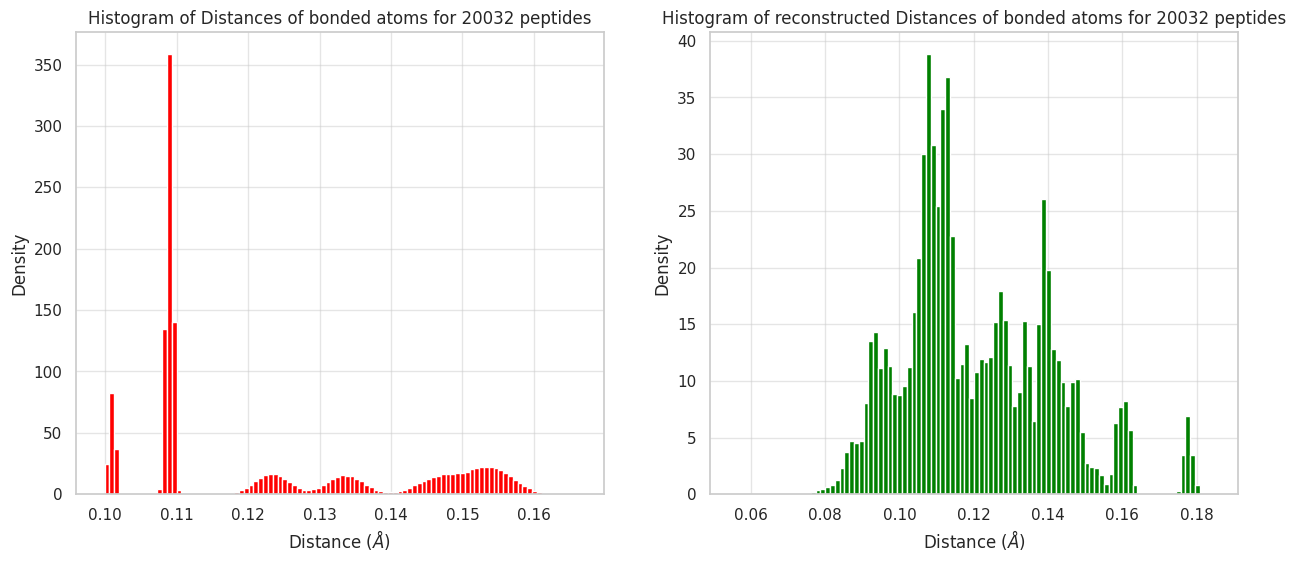

In [161]:
# plot fig_original and fig_reconstructed side by side
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].hist(true_distances, bins=100, color ='red', density=True)
ax[0].set_xlabel(r'Distance ($\AA$)')
ax[0].set_ylabel('Density')
ax[0].set_title(f'Histogram of Distances of bonded atoms for {n_peptides} peptides')
ax[0].grid(alpha=0.5)
ax[1].hist(distances, bins=100, color ='green', density=True)
ax[1].set_xlabel(r'Distance ($\AA$)')
ax[1].set_ylabel('Density')
ax[1].set_title(f'Histogram of reconstructed Distances of bonded atoms for {n_peptides} peptides')
ax[1].grid(alpha=0.5)
plt.show()


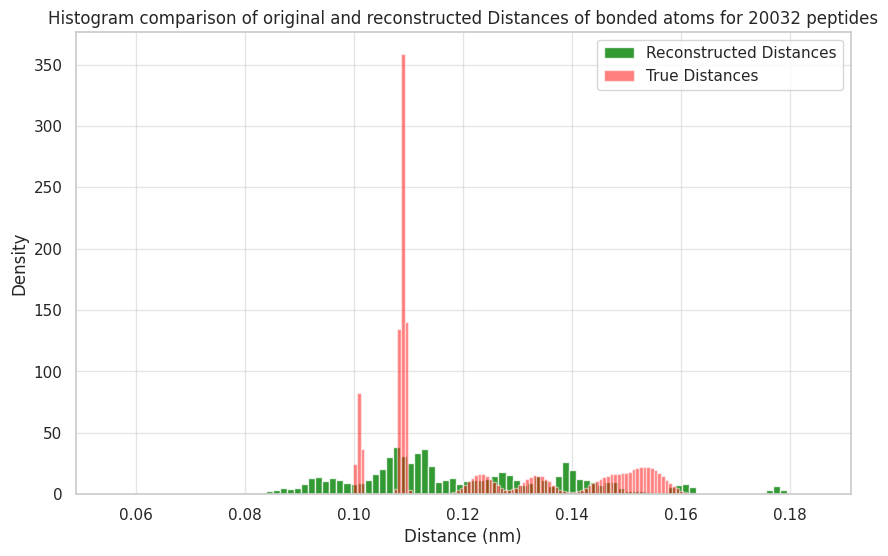

In [162]:
plt.figure(figsize=(10, 6))
plt.hist(distances, bins=100, density=True, alpha=0.8, color='green', label='Reconstructed Distances')
plt.hist(true_distances, bins=100, density=True, alpha=0.5, color='red', label='True Distances')
plt.xlabel(r'Distance (nm)')
plt.ylabel('Density')
plt.title(f'Histogram comparison of original and reconstructed Distances of bonded atoms for {n_peptides} peptides')
plt.legend()
plt.grid(alpha=0.5)
plt.show()


**Typical atomic size**

| **Element**      | **Covalent Radius** (Å) | **Van der Waals Radius** (Å) |
| ---------------- | ----------------------- | ---------------------------- |
| **Hydrogen (H)** | \~0.31 Å                | \~1.20 Å                     |
| **Carbon (C)**   | \~0.76 Å                | \~1.70 Å                     |
| **Nitrogen (N)** | \~0.71 Å                | \~1.55 Å                     |
| **Oxygen (O)**   | \~0.66 Å                | \~1.52 Å                     |

- Covalent radius: Half the distance between two atoms of the same kind bonded together.

- Van der Waals radius: Effective size an atom appears to occupy in space; important for non-bonded interactions.


In [163]:
import sys
sys.path.append("LIBS")
from LIBS.force_field import *


In [164]:
pos_recon_rescaled_tensor.shape

torch.Size([20032, 52, 3])

In [165]:
pdbfile = '../DATA/raw/protein_only.pdb'
physics_critic = EnergyCalculator(pdbfile)

energies = [physics_critic(pos) for pos in pos_recon_rescaled_tensor]
energies = torch.tensor(energies).cpu().numpy()

true_energies = [physics_critic(data.pos) for data in dataset]
true_energies = torch.tensor(true_energies).cpu().numpy()

Using OpenMM platform: CUDA


In [166]:
pred_en = 5*energies[:,0] + 2*energies[:,1]
true_en = 5*true_energies[:,0] + 2*true_energies[:,1]

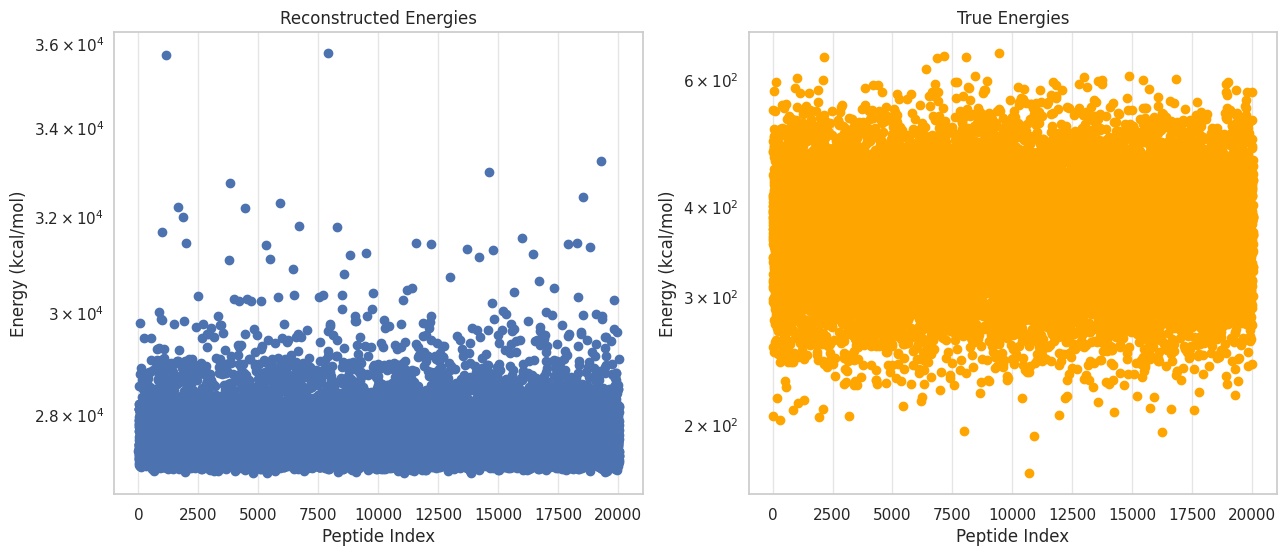

In [ ]:
# create to subplots with the energies
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].plot(np.arange(len(pred_en)), pred_en, 'o', label='Reconstructed Energies')
ax[0].set_xlabel('Peptide Index')
ax[0].set_yscale('log')
ax[0].set_ylabel('Energy (kJ/mol)')
#ax[0].set_ylim(energies.min(), 1e5)
ax[0].set_title('Reconstructed Energies')
ax[0].grid(alpha=0.5)   

ax[1].plot(np.arange(len(true_en)), true_en, 'o', label='True Energies', color='orange')
ax[1].set_xlabel('Peptide Index')
ax[1].set_ylabel('Energy (kJ/mol)')
ax[1].set_yscale('log')
ax[1].set_title('True Energies')
ax[1].grid(alpha=0.5)

In [168]:
# extract the dihedral angles from th reconstructed positions
def get_dihedral_angles(pos,backbone_indices = None):
    """
    Calculate dihedral angles for the backbone atoms in the graph.
    
    Args:
        graph (Data): The graph data containing node positions.
        backbone_indices (list): Indices of the backbone atoms.
        
    Returns:
        list: Dihedral angles in radians.
    """
    if backbone_indices is None:
        backbone_indices = [4,6,8,14,16,18,24,26,28,34,36,38,44,46]

    angles = []
    for i in range(len(backbone_indices) - 3):
        p1 = pos[backbone_indices[i]]
        p2 = pos[backbone_indices[i + 1]]
        p3 = pos[backbone_indices[i + 2]]
        p4 = pos[backbone_indices[i + 3]]

    

        b1 = p2 - p1
        b2 = p3 - p2
        b3 = p4 - p3

        # Calculate normals to the two planes
        n1 = torch.cross(b1, b2)
        n2 = torch.cross(b2, b3)

        # Normalize normals (important for arccos stability)
        n1_norm = n1 / torch.linalg.norm(n1)
        n2_norm = n2 / torch.linalg.norm(n2)

        # Calculate cosine of the angle between normals
        cos_angle = torch.dot(n1_norm, n2_norm)
        
        # Ensure cos_angle is within the valid range for arccos to avoid NaN
        cos_angle = torch.clip(cos_angle, -1.0, 1.0)
        angle_rad = torch.arccos(cos_angle)

        # Determine the sign of the angle
        # The sign is positive if b3 points to the same side of the b1-b2 plane as n1 x n2
        # Or, more simply, check the sign of the triple product (n1, n2, b2)
        # or (b1, n2, b2_normalized) as per some definitions
        if torch.dot(torch.cross(n1_norm, n2_norm), b2 / torch.linalg.norm(b2)) > 0:
            angle_deg = np.degrees(angle_rad.detach().numpy())
        else:
            angle_deg = -np.degrees(angle_rad.detach().numpy())

        angles.append(angle_deg.item())
            
    return angles

In [169]:
dihedral_angles_list = []
for data in dataset:
    dihedral_angles = get_dihedral_angles(data.pos)
    dihedral_angles_list.append(dihedral_angles)


columns_names = [ "Phi_1", "Psi_1", "Omega_1", "Phi_2", "Psi_2", "Omega_2", "Phi_3", "Psi_3", "Omega_3", "Phi_4", "Psi_4"]

df_dataset = pd.DataFrame(dihedral_angles_list, columns=columns_names)

# convert angles from radians to degrees
#df_dataset = df_dataset.applymap(lambda x: np.degrees(x) if isinstance(x, (int, float)) else x)

df_dataset

,Phi_1,Psi_1,Omega_1,Phi_2,Psi_2,Omega_2,Phi_3,Psi_3,Omega_3,Phi_4,Psi_4
0,-131.160614,145.743225,169.970688,-137.721298,159.032196,167.127853,-142.836288,144.440048,176.366806,-137.981384,156.916641
1,-57.785332,125.849182,171.549957,-93.953667,159.210068,-176.857758,-65.798035,144.862640,164.410370,-75.925072,138.219467
2,-68.451706,164.619003,173.799255,-57.912251,141.092407,-179.671936,-125.266273,160.505676,176.876251,-72.660225,151.342316
3,-80.006744,-34.772579,163.340057,-62.796474,-42.952091,165.036758,-58.280579,-31.043530,174.295685,-58.819054,-34.341110
4,-64.699921,-44.467480,179.451767,-87.758087,1.220451,-178.037552,-102.640366,-71.340912,-170.809006,-152.000290,153.048340
...,...,...,...,...,...,...,...,...,...,...,...
20027,-61.179546,-35.261353,175.766846,-58.174870,-12.885231,165.689514,61.709362,28.749374,179.439758,59.407444,-11.024766
20028,-55.565800,-19.692375,-165.809692,-106.723999,-5.713539,-168.381439,55.166481,22.075287,-164.497757,59.051647,17.663069
20029,-82.897240,51.421337,-168.820938,-69.020065,1.343775,-176.098907,56.645096,38.485771,-169.040009,61.617222,2.731081
20030,-105.517586,150.130692,-167.690750,-60.311703,-22.302486,-178.664398,-133.560730,138.050171,-176.385712,56.117554,164.094177


In [170]:
rec_dihedral_angles_list = []
for pos in pos_recon_rescaled_tensor:
    rec_dihedral_angles = get_dihedral_angles(pos)
    rec_dihedral_angles_list.append(rec_dihedral_angles)

columns_names = [ "Phi_1", "Psi_1", "Omega_1", "Phi_2", "Psi_2", "Omega_2", "Phi_3", "Psi_3", "Omega_3", "Phi_4", "Psi_4"]

df_rec_dataset = pd.DataFrame(rec_dihedral_angles_list, columns=columns_names)

# convert angles from radians to degrees
#df_rec_dataset = df_rec_dataset.applymap(lambda x: np.degrees(x) if isinstance(x, (int, float)) else x)

df_rec_dataset

,Phi_1,Psi_1,Omega_1,Phi_2,Psi_2,Omega_2,Phi_3,Psi_3,Omega_3,Phi_4,Psi_4
0,-146.573853,154.582138,-177.236130,-125.625938,147.574356,-177.587509,-101.254745,128.912170,-173.669617,-123.551842,155.512238
1,-146.188416,151.833405,-179.229233,-127.650902,148.354813,-176.913376,-101.801643,130.536880,-173.437973,-123.980537,156.261963
2,-145.327209,158.646713,-174.965561,-126.134216,147.340881,-177.461945,-101.356133,129.125336,-173.541183,-124.174690,155.381378
3,-145.205902,158.814819,-174.488495,-127.493263,148.756577,-176.566406,-102.347168,130.400803,-173.132095,-124.000305,156.014221
4,-146.539963,150.694763,-179.467712,-126.293785,146.513550,-177.836334,-99.299400,128.113174,-173.188385,-124.553680,155.164810
...,...,...,...,...,...,...,...,...,...,...,...
20027,-144.940567,159.476639,-173.545532,-127.435242,148.458511,-176.565430,-101.725891,129.697342,-172.845123,-124.223373,155.792801
20028,-145.396515,157.611603,-174.094498,-127.874245,149.555923,-176.213623,-102.948616,130.993622,-172.988815,-123.826088,156.366531
20029,-147.363602,152.032440,-178.872208,-128.098419,149.958466,-176.468353,-102.874443,131.886475,-173.602203,-123.592728,156.926682
20030,-147.748352,150.006897,-179.627792,-126.610840,148.309036,-177.527161,-101.475906,130.168900,-173.915817,-123.715141,156.100403


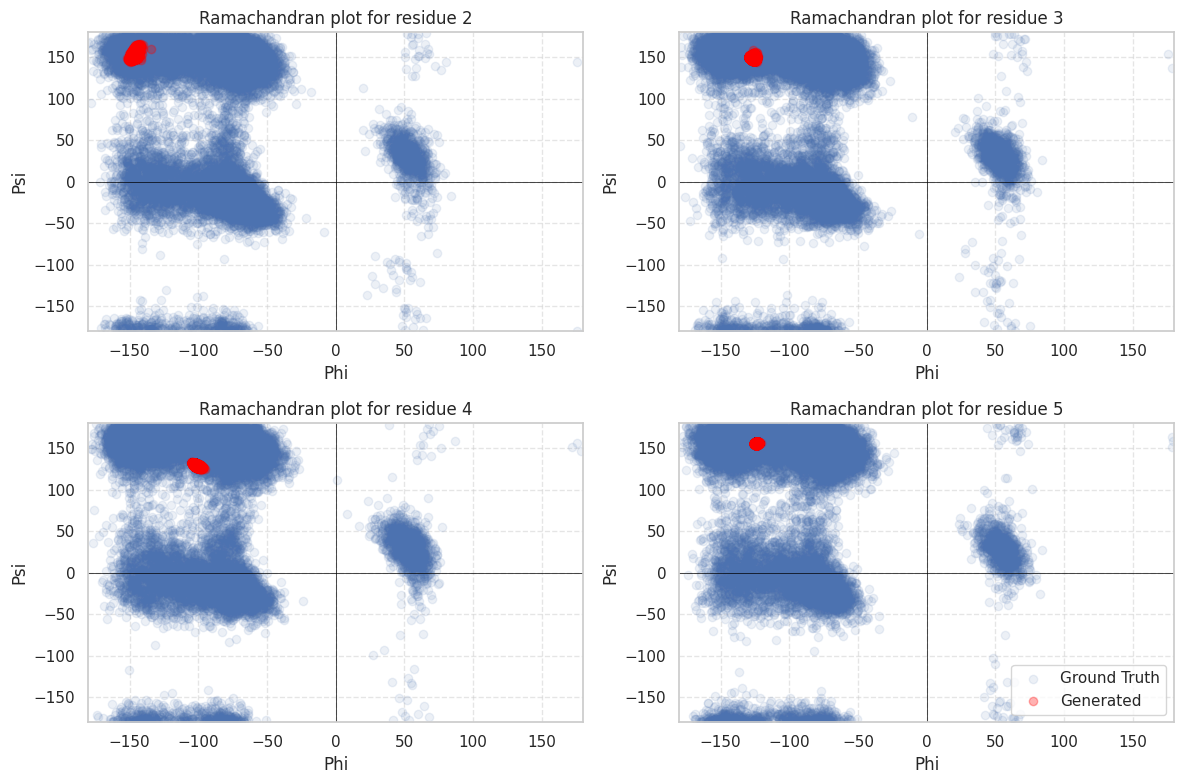

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

for i in range(4):
    phi = df_dataset[f'Phi_{i+1}']
    psi = df_dataset[f'Psi_{i+1}']

    psi_gen = df_rec_dataset[f'Psi_{i+1}']
    phi_gen = df_rec_dataset[f'Phi_{i+1}']


    plt.subplot(2, 2, i+1)
    plt.scatter(phi, psi, alpha=0.1, label = "Ground Truth")
    plt.scatter(phi_gen, psi_gen, alpha=0.3, color='red', label='Generated')
    plt.xlim(-180, 180)
    plt.ylim(-180, 180)
    plt.xlabel('Phi')
    plt.ylabel('Psi')
    plt.title(f'Ramachandran plot for residue {i+2}')
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
#plt.savefig(os.path.join(model_path, f'generated_from_prior_{EPOCH}_epochs.png'))

plt.show()

In [172]:
data_ref = dataset[0]
model.eval()
gen_dataset = [data_ref.cpu()]  # Start with the reference structure

data_ref = data_ref.to(device)  # Move to device

batch = torch.tensor([0] * len(data_ref.pos), dtype=torch.long, device=device)  # Assuming all data belongs to batch 0


for i in range(100):
    #z = torch.randn(2, LATENT_DIM).to(device)  # Random latent vector for generation
    print(z)
    #z = torch.cat([z[0], z[1]])  # Ensure z is a tensor
    z = z.to(device)  # Move to device
    batch = batch.to(device)  # Move to device
    pos_pred = model.decoder.forward(z,data_ref.x,data_ref.edge_index, batch, pos_ref=data_ref.pos)
    pred_graph = Data(pos=pos_pred, edge_index=data_ref.edge_index, x=data_ref.x).cpu().detach()
    gen_dataset.append(pred_graph)


tensor([[ 3.7943e-04, -5.5581e-04,  6.8818e-04, -2.4178e-04, -1.5918e-04,
          5.4632e-04],
        [-1.6704e-04, -3.5858e-04,  5.2748e-05, -1.4084e-04,  3.1228e-04,
          3.6696e-04]], device='cuda:0')
tensor([[ 3.7943e-04, -5.5581e-04,  6.8818e-04, -2.4178e-04, -1.5918e-04,
          5.4632e-04],
        [-1.6704e-04, -3.5858e-04,  5.2748e-05, -1.4084e-04,  3.1228e-04,
          3.6696e-04]], device='cuda:0')
tensor([[ 3.7943e-04, -5.5581e-04,  6.8818e-04, -2.4178e-04, -1.5918e-04,
          5.4632e-04],
        [-1.6704e-04, -3.5858e-04,  5.2748e-05, -1.4084e-04,  3.1228e-04,
          3.6696e-04]], device='cuda:0')
tensor([[ 3.7943e-04, -5.5581e-04,  6.8818e-04, -2.4178e-04, -1.5918e-04,
          5.4632e-04],
        [-1.6704e-04, -3.5858e-04,  5.2748e-05, -1.4084e-04,  3.1228e-04,
          3.6696e-04]], device='cuda:0')
tensor([[ 3.7943e-04, -5.5581e-04,  6.8818e-04, -2.4178e-04, -1.5918e-04,
          5.4632e-04],
        [-1.6704e-04, -3.5858e-04,  5.2748e-05, -1.4084

In [173]:
z

tensor([[ 3.7943e-04, -5.5581e-04,  6.8818e-04, -2.4178e-04, -1.5918e-04,
          5.4632e-04],
        [-1.6704e-04, -3.5858e-04,  5.2748e-05, -1.4084e-04,  3.1228e-04,
          3.6696e-04]], device='cuda:0')

In [174]:
# convert tuple to tensor


In [175]:
data_ref = data_ref.to(device)
z_list = []
model.encoder.eval()
for data in dataset:
    data = data.to(device)  # Ensure data is on the correct device
    with torch.no_grad():
        z = model.encoder.forward(data.x,data.pos, data.edge_index,batch)
        z = torch.stack([z[0][0], z[1][0]],dim=1).T
    z_list.append(z)

In [176]:
z__stacked = torch.stack(z_list, dim=0)  # Stack all z vectors into a single tensor
z__stacked[0][1]

tensor([-0.0039, -0.0620, -0.0667, -0.0566, -0.1414, -0.0207], device='cuda:0')

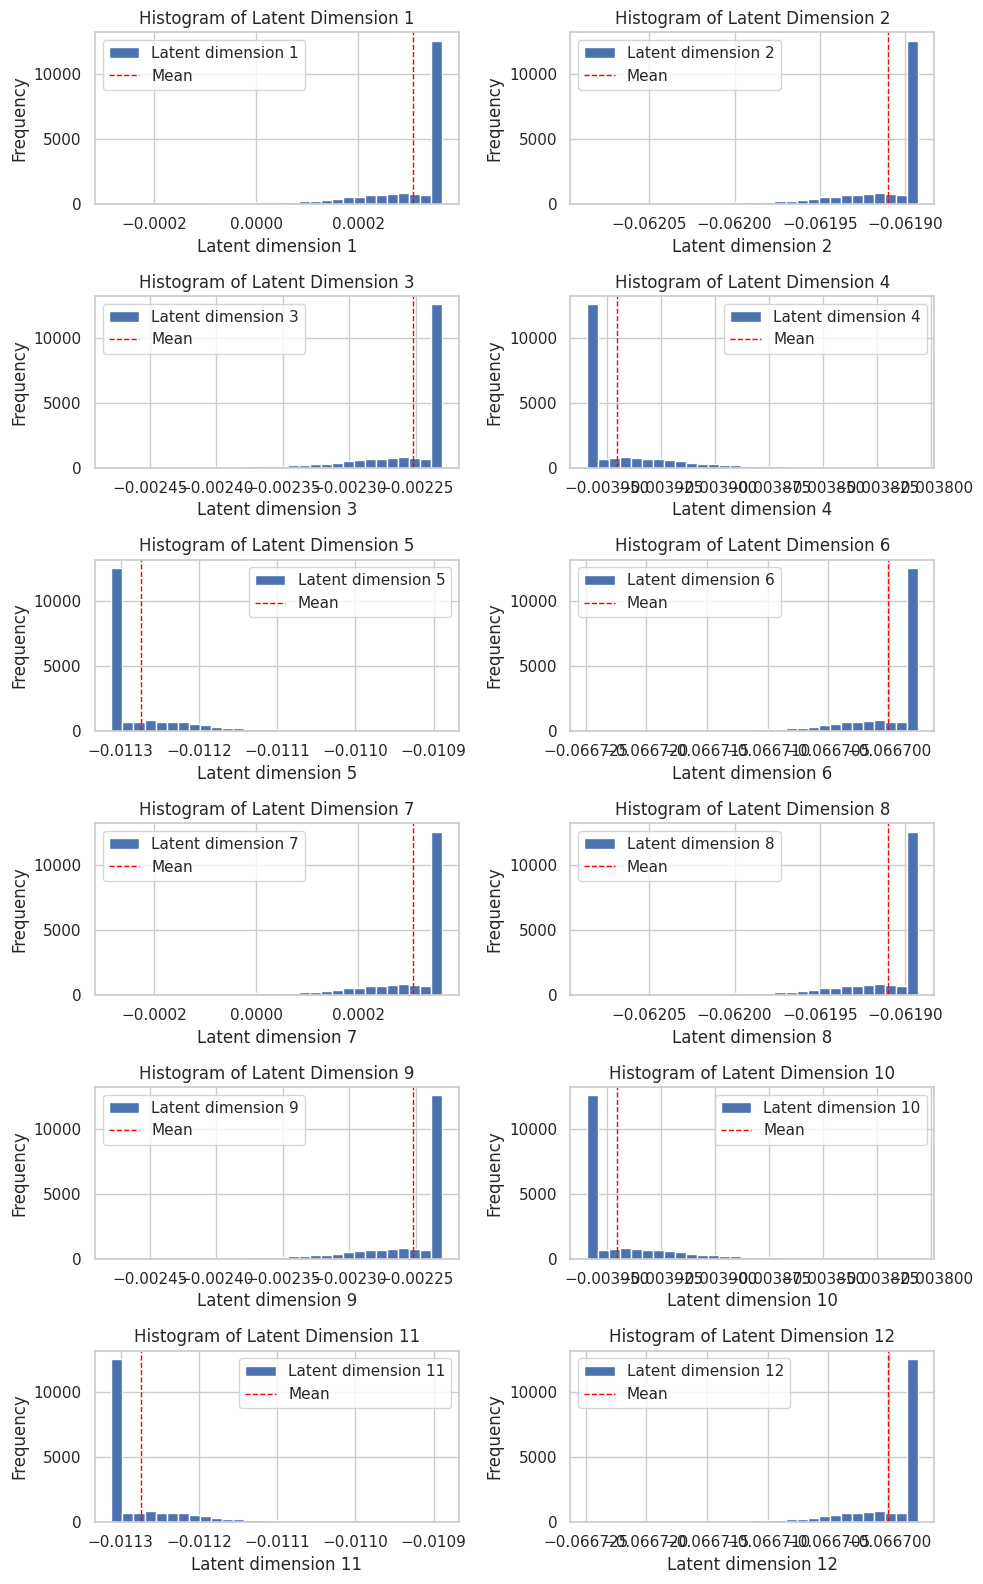

In [177]:
plt.figure(figsize=(10, 16))
for i in range(12):
    z_i = torch.stack([z[i%2][i%3].cpu() for z in z__stacked])

    plt.subplot(6, 2, i+1)
    plt.hist(z_i, bins=30, alpha=1, label=f'Latent dimension {i+1}')
    plt.xlabel(f'Latent dimension {i+1}')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Latent Dimension {i+1}')
    plt.axvline(z_i.mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
    #plt.axvline(z_i.std(), color='green', linestyle='dashed', linewidth=1, label='Std Dev')
    plt.legend()
    #plt.xlim(-3, 3)
    #plt.ylim(0, 100)
plt.tight_layout()
#plt.savefig(os.path.join(model_path, f'latent_distribution_{EPOCH}_epochs.png'))
plt.show()

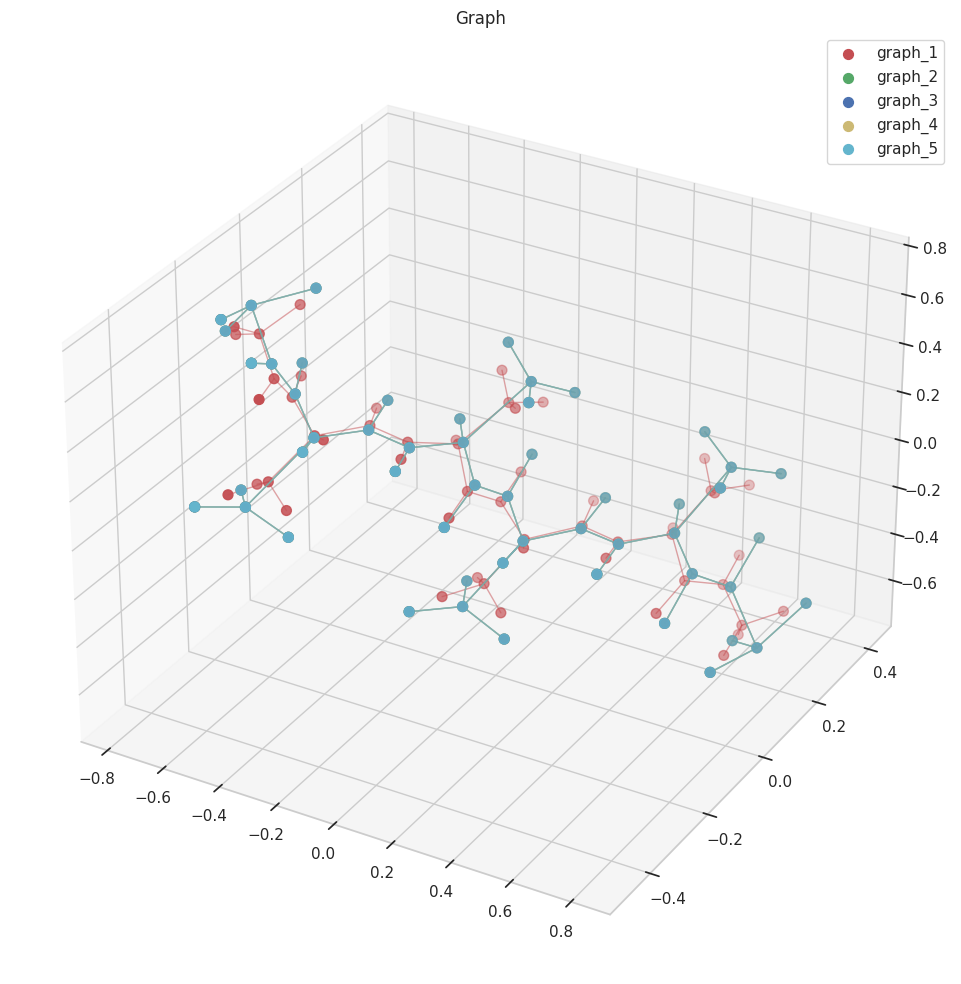

In [178]:
gen_dataset = [data.cpu() for data in gen_dataset]  # Move all generated graphs to CPU
plot_graph_dataset(gen_dataset,5)
